# KNN Regression

Predicts a continuous numerical value for a new data point by averaging the target values of its 'K' closest neighbor.

- Instead of a "majority vote", it calculates the mean (or median) of neighbors values.
- We can use 'weights=distance' so closer neighbors have a bigger impoact on the final average.
- Highly sensitive to unscaled data and outliers.


**Input:**

`Features → Continuous Value`

**Output:**

`Number`

**Decision:**

`Average of Neighbors`

In [1]:
import numpy as np 

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
from sklearn.datasets import fetch_california_housing

In [3]:
housing_data = fetch_california_housing() 

X = housing_data.data
y = housing_data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [4]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

knn_regressor = KNeighborsRegressor(n_neighbors=5)

knn_regressor.fit(X_train, y_train) 

y_train_pred = knn_regressor.predict(X_train)
y_test_pred = knn_regressor.predict(X_test)


# Evaluation

print("MAE:", mean_absolute_error(y_test, y_test_pred))

print("RMSE:",np.sqrt(mean_squared_error(y_test, y_test_pred)))

print("R2:",r2_score(y_test, y_test_pred))


MAE: 0.4461535271317829
RMSE: 0.6575877238850522
R2: 0.6700101862970989


In [5]:
k_values = range(1,30)

R2 = []
errors = []


for k in k_values:

    model = KNeighborsRegressor(n_neighbors=k)

    model.fit(X_train, y_train)

    prediction = model.predict(X_test)

    r2 = r2_score(y_test, prediction)
    
    rmse = np.sqrt(mean_squared_error(y_test, prediction))

    R2.append(r2)
    errors.append(rmse)

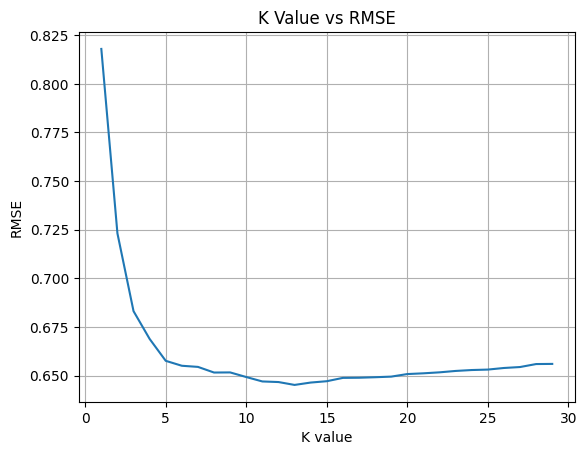

In [6]:
import matplotlib.pyplot as plt


plt.plot(
    list(k_values),
    errors
)

plt.xlabel("K value")
plt.ylabel("RMSE")

plt.title("K Value vs RMSE")

plt.grid()
plt.show()

In [7]:
# Best RMSE
best_rmse_index = np.argmin(errors)
print("Best K based on RMSE:",
    list(k_values)[best_rmse_index])

print("Lowest RMSE:",
    errors[best_rmse_index])

# Best R2
best_r2_index = np.argmax(R2)
print("Best K based on R2:",
    list(k_values)[best_r2_index])

print("Highest R2:",
    R2[best_r2_index])

Best K based on RMSE: 13
Lowest RMSE: 0.6452046222487675
Best K based on R2: 13
Highest R2: 0.6823213122898445
